# Работа с целевой переменной

## Цель работы

Познакомиться с основными приемами обработки данных в отношении к целевой переменной: дискретизация, отбор признаков, устранение дисбаланса классов.

## 1. Отбор признаков по важности

### Загрузка датасета

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

df = fetch_openml('mtp', version=1)
df.data.head()

,oz1,oz2,oz3,oz4,oz5,oz6,oz7,oz8,oz9,oz10,...,oz193,oz194,oz195,oz196,oz197,oz198,oz199,oz200,oz201,oz202
0,0.076923,0.325000,0.035088,0.200000,0.162112,0.194562,0.003900,0.060606,0.166667,0.045872,...,0.013874,0.071602,0.056880,0.179132,0.505899,0.039213,0.091327,0.321109,0.127564,0.188387
1,0.230769,0.375000,0.042105,0.333333,0.464191,0.622795,0.077623,0.373737,0.305556,0.192661,...,0.006342,0.186056,0.287438,0.384236,0.683820,0.326584,0.117990,0.456665,0.475618,0.401935
2,0.269231,0.437500,0.052632,0.333333,0.506556,0.531840,0.054374,0.212121,0.333333,0.229358,...,0.005018,0.179544,0.117431,0.384550,0.499219,0.204885,0.155967,0.360441,0.497968,0.407742
3,0.153846,0.357143,0.039474,0.266667,0.352880,0.394131,0.019654,0.171717,0.277778,0.091743,...,0.004801,0.091771,0.145349,0.243064,0.630533,0.023469,0.124430,0.336023,0.134458,0.252258
4,0.153846,0.357143,0.039474,0.266667,0.350523,0.320546,0.013154,0.101010,0.166667,0.110092,...,0.011166,0.130755,0.067583,0.250832,0.516053,0.111398,0.125693,0.332113,0.295913,0.253548


Распределение целевой переменной:

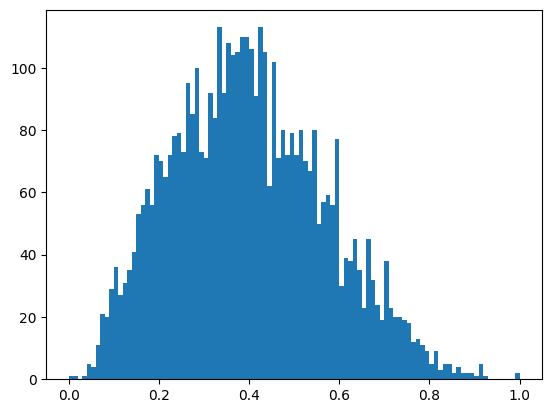

In [2]:
plt.hist(df.target, 100)
_ = plt.plot()

### Построение базовой (baseline) модели

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

baseline = LinearRegression()
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
bl_score

-1.6511340766953149

### Определение относительной важности признаков (Random Forest)

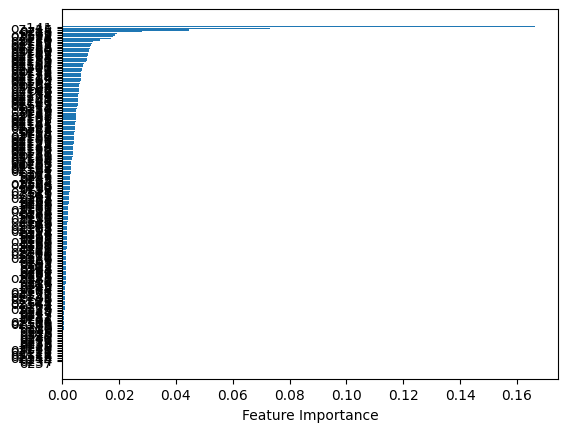

In [4]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=15).fit(X_train, y_train)

sort = rf.feature_importances_.argsort()
plt.barh(df.data.columns[sort], rf.feature_importances_[sort])
plt.xlabel('Feature Importance')
plt.show()

10 самых важных признаков:

In [5]:
print(rf.feature_importances_[sort][-10:])
print(df.data.columns[sort][-10:])

[0.01066648 0.01321501 0.01705592 0.01786279 0.01845299 0.01915184
 0.0281468  0.0446904  0.07314306 0.16618028]
Index(['oz155', 'oz20', 'oz170', 'oz18', 'oz197', 'oz112', 'oz35', 'oz48',
       'oz15', 'oz141'],
      dtype='str')


### Модель на отобранных признаках

In [6]:
trimmed = df.data[df.data.columns[sort][-20:]]

X_train, X_test, y_train, y_test = train_test_split(trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)
print('Baseline R2:', bl_score)
print('Improved R2:', better.score(X_test, y_test))

Baseline R2: -1.6511340766953149
Improved R2: 0.3686239948535037


## 2. Автоматизация отбора признаков (SelectFromModel)

In [7]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(RandomForestRegressor(n_estimators=15)).fit(df.data, df.target)
X_trimmed = sfm.transform(df.data)
print('Shape after selection:', X_trimmed.shape)

Shape after selection: (4450, 50)


Оценка модели на автоматически отобранных признаках:

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_trimmed, df.target, test_size=0.25, random_state=42)

better = LinearRegression()
better.fit(X_train, y_train)
print('Baseline R2:', bl_score)
print('Auto-selected R2:', better.score(X_test, y_test))

Baseline R2: -1.6511340766953149
Auto-selected R2: 0.4454783867774933


## 3. Устранение дисбаланса классов

### Загрузка датасета balance-scale

In [9]:
df = fetch_openml('balance-scale', version=1)
df.data.head()

,left-weight,left-distance,right-weight,right-distance
0,1,1,1,1
1,1,1,1,2
2,1,1,1,3
3,1,1,1,4
4,1,1,1,5


Визуализируем распределение целевой переменной:

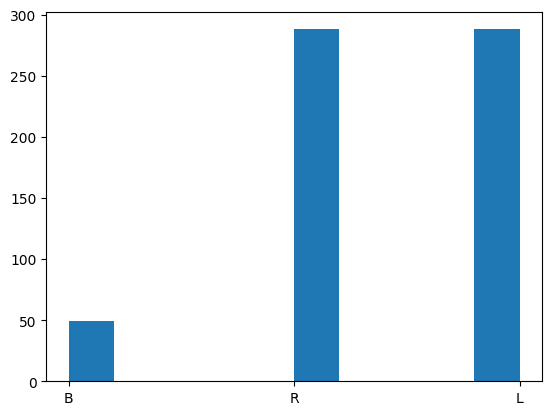

In [10]:
plt.hist(df.target)
plt.show()

### Разделение со стратификацией

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df.data, df.target, test_size=0.25, random_state=42, stratify=df.target
)

### Базовая модель классификации

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)
bl_score = baseline.score(X_test, y_test)
print('Accuracy:', bl_score)
print(classification_report(y_test, baseline.predict(X_test)))

Accuracy: 0.8598726114649682
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        12
           L       0.87      0.92      0.89        73
           R       0.86      0.94      0.90        72

    accuracy                           0.86       157
   macro avg       0.58      0.62      0.60       157
weighted avg       0.80      0.86      0.83       157



Матрица ошибок:

In [13]:
print(confusion_matrix(y_test, baseline.predict(X_test)))

[[ 0  6  6]
 [ 1 67  5]
 [ 0  4 68]]


### Взвешивание классов

In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights

{'B': np.float64(4.216216216216216),
 'L': np.float64(0.7255813953488373),
 'R': np.float64(0.7222222222222222)}

In [15]:
weighted = LogisticRegression(class_weight=class_weights, max_iter=1000)
weighted.fit(X_train, y_train)
print('Baseline:', bl_score)
print('Weighted accuracy:', weighted.score(X_test, y_test))
print(classification_report(y_test, weighted.predict(X_test)))

Baseline: 0.8598726114649682
Weighted accuracy: 0.9235668789808917
              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



### Oversampling

In [16]:
print('Original train distribution:')
print(y_train.value_counts())

Original train distribution:
class
R    216
L    215
B     37
Name: count, dtype: int64


In [17]:
X_train['target'] = y_train
oversampled = X_train[X_train.target == 'B'].sample(n=216-37, replace=True, ignore_index=True)
oversampled = pd.concat([X_train, oversampled])
print('Shape after oversampling:', oversampled.shape)

Shape after oversampling: (647, 5)


Распределение после оверсемплинга:

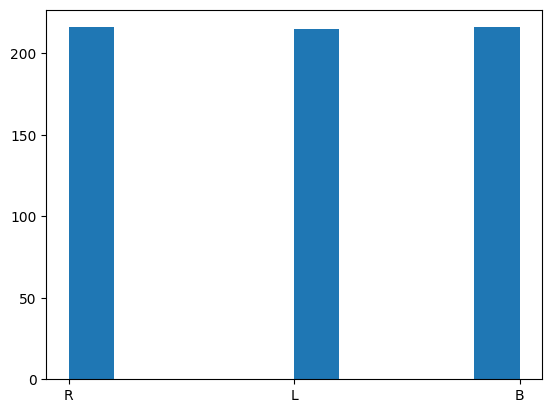

In [18]:
plt.hist(oversampled.target)
plt.show()

Обучение модели на oversampled данных:

In [19]:
y_train_OS = oversampled.target
X_train_OS = oversampled.drop(['target'], axis=1)

OSmodel = LogisticRegression(max_iter=1000)
OSmodel.fit(X_train_OS, y_train_OS)
print('Baseline:', bl_score)
print('Oversampled accuracy:', OSmodel.score(X_test, y_test))
print(classification_report(y_test, OSmodel.predict(X_test)))

Baseline: 0.8598726114649682
Oversampled accuracy: 0.9235668789808917
              precision    recall  f1-score   support

           B       0.61      0.92      0.73        12
           L       0.97      0.92      0.94        73
           R       0.96      0.93      0.94        72

    accuracy                           0.92       157
   macro avg       0.85      0.92      0.87       157
weighted avg       0.94      0.92      0.93       157



## 4. Дискретизация целевой переменной

In [20]:
df = fetch_openml('CPMP-2015-regression', version=1)
df.data.drop(['instance_id'], inplace=True, axis=1)
df.data = pd.get_dummies(df.data)
df.data.head()

,repetition,stacks,tiers,stack.tier.ratio,container.density,empty.stack.pct,overstowing.stack.pct,overstowing.2cont.stack.pct,group.same.min,group.same.max,...,avg.l1.top.left.lg.group,cont.empty.grt.estack,pct.bottom.pct.on.top,algorithm_astar.symmulgt.transmul,algorithm_astar.symmullt.transmul,algorithm_idastar.symmulgt.transmul,algorithm_idastar.symmullt.transmul,runstatus_memout,runstatus_ok,runstatus_timeout
0,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,True,False,False,False,False,True,False
1,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,True,False,False,False,True,False
2,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,True,False,False,True,False
3,1,16,5,0.3125,0.6,0.0625,0.6250,0.909091,0,6,...,0.509615,0.1750,0.0,False,False,False,True,False,False,True
4,1,16,5,0.3125,0.6,0.1875,0.5625,1.000000,0,7,...,0.663462,0.3375,0.0,True,False,False,False,True,False,False


Распределение целевой переменной:

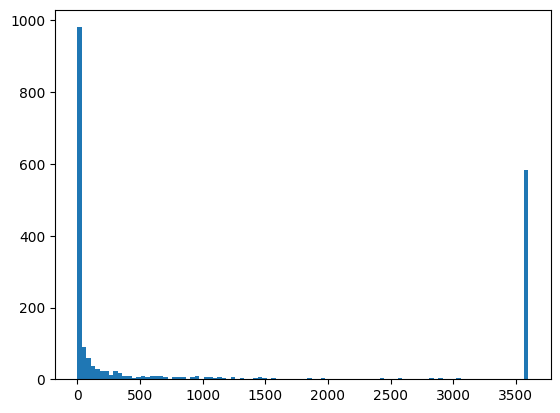

In [21]:
plt.hist(df.target, 100)
_ = plt.plot()

Разделение выборки:

In [22]:
X_train, X_test, y_train, y_test = train_test_split(df.data, df.target, test_size=0.25, random_state=42)

Равномерная дискретизация (5 бинов):

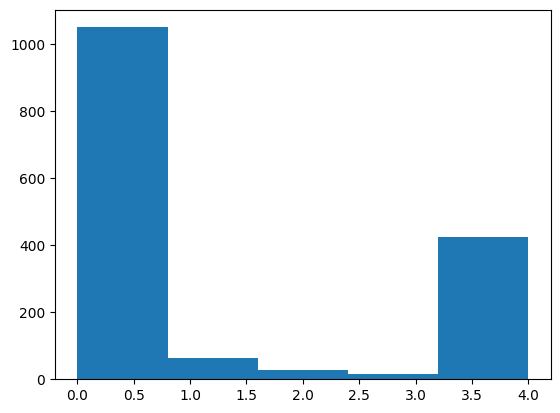

In [23]:
from sklearn.preprocessing import KBinsDiscretizer

y_binned = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform').fit_transform(pd.DataFrame(y_train))
plt.hist(y_binned, bins=5)
plt.show()

Квантильная дискретизация (5 бинов):

c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


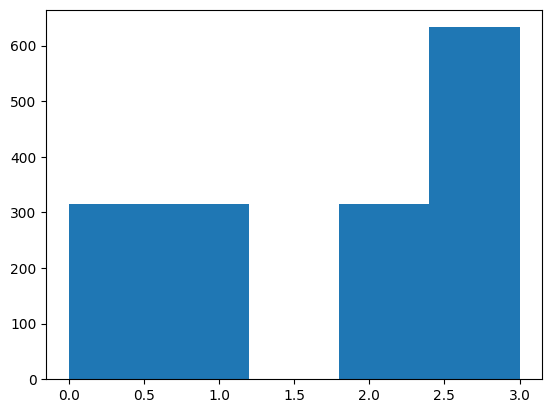

In [24]:
y_binned = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile').fit_transform(pd.DataFrame(y_train))
plt.hist(y_binned, bins=5)
plt.show()